In [2]:
import sys
!{sys.executable} -m pip install numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 80.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 66.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 86.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

In [5]:
f(3)

20

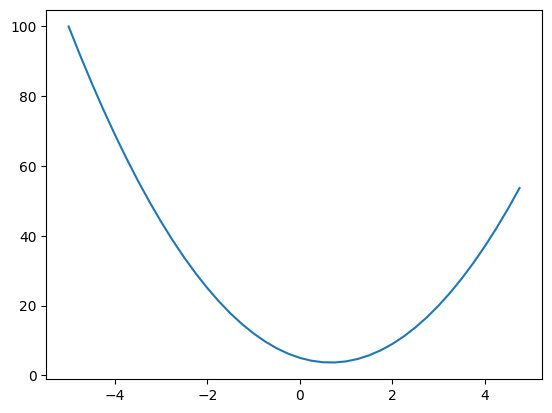

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)
plt.show()


In [8]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h


2.999378523327323e-06

In [253]:
class Value:
    def __init__(self,data, _children=(), _op='',label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0.0
        self._backward = lambda: None
        self._op = _op
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other):
        return self * other
    
    def __truediv__(self,other):
        return self * (other**-1)
    def __neg__(self):
        return self * -1
    def __sub__(self,other):
        return self + (-other)
    

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

# a = Value(2.0,label='a')
# b = Value(-3.0,label='b')
# c = Value(4.0,label='c')
# e = a + b; e.label = 'e'
# d = e * c; d.label = 'd'
# d
# f = Value(2.0,label='f')
# L = d * f; L.label = 'L'
# L

    

In [134]:
a = Value(2.0,label='a')
b = Value(3.0,label='b')
a + 2
a * 3
2 * a
a.exp()
a / b
a - b

Value(data=-1.0)

In [19]:
d._prev

{Value(data=-6.0), Value(data=4.0)}

In [23]:
d._op

'*'

In [30]:
%pip install graphviz


  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label,n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

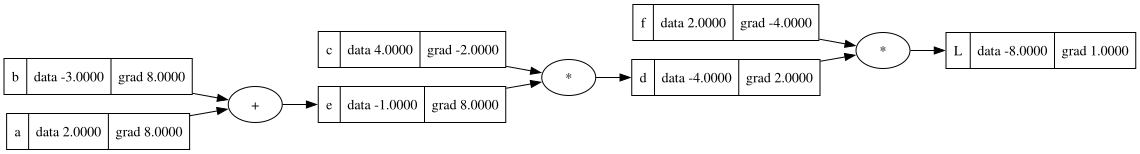

In [72]:
draw_dot(L)

In [74]:

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a + b
d = e * c
L = d * f

print(L.data)

f.grad = -4.0
d.grad = 2.0

# dL/dc = dL/dd * dd/dc
# dd/dc = e 
# dL/dc = 2.0 * e
c.grad = -2.0
# dL/de = dL/dd * dd/de
# dd/de = c
# dL/de = 2.0 * c
e.grad = 8.0

# dL/da = dL/de * de/da
# de/da = 8.0
# de/da = 1.0

# dL/db = dL/de * de/db
# dL/de = 8.0
# de/db = 1.0
b.grad = 8.0
a.grad = 8.0




-6.5526719999999985


In [60]:
L.grad = 1.0

In [73]:
def lol():
    h = 0.0001
    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c = Value(4.0,label='c')
    e = a + b; e.label = 'e'
    d = e * c; d.label = 'd'
    f = Value(2.0,label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0+h,label='a')
    b = Value(-3.0,label='b')
    c = Value(4.0,label='c')
    e = a + b; e.label = 'e'
    d = e * c; d.label = 'd'
    f = Value(2.0,label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()


8.000000000016882


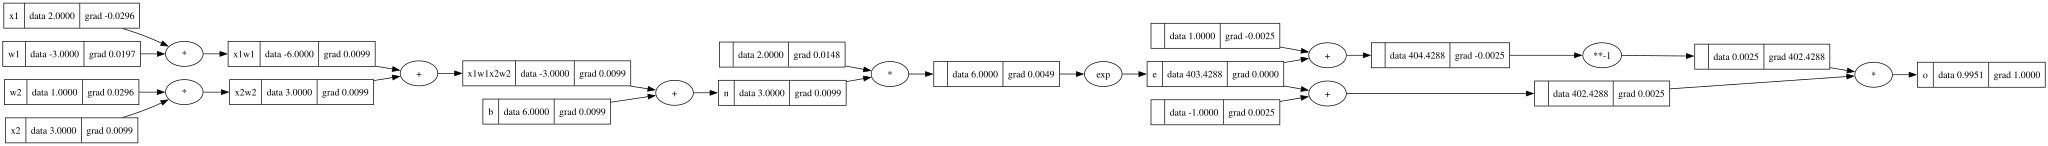

In [136]:
x1 = Value(2.0,label='x1')
x2 = Value(3.0,label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
b = Value(6.0,label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2 * n).exp(); e.label = 'e'
o = (e - 1)/(e + 1); o.label = 'o'
# o = n.tanh(); o.label = 'o'
o.grad = 1.0
# n.grad = 1 - o.data**2
# b.grad = n.grad
# x1w1x2w2.grad = n.grad
# x1w1.grad = b.grad
# x2w2.grad = b.grad
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# b._backward()
# x2._backward()
# w2._backward()

o.backward()
draw_dot(o)



In [ ]:
%pip install torch








   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 56.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 50.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 27.7 MB/s  0:00:00
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [sympy]
    Found existing installation: setuptools 82.0.0━━━━━━━━━━━━ 1/9 [sympy]
    Uninstalling setuptools-82.0.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [sympy]
      Successfully uninstalled setuptools-82.0.0━━━━━━━━━━━━━━━━━━ 2/9 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [torch]32m8/9 [torch]]x]s]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated package

In [141]:
import torch

x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(3.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(6.0, requires_grad=True)

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print(x1.grad.item())
print(x2.grad.item())
print(w1.grad.item())
print(w2.grad.item())
print(b.grad.item())


0.9950547814369202
-0.029597945511341095
0.00986598152667284
0.01973196305334568
0.029597945511341095
0.00986598152667284


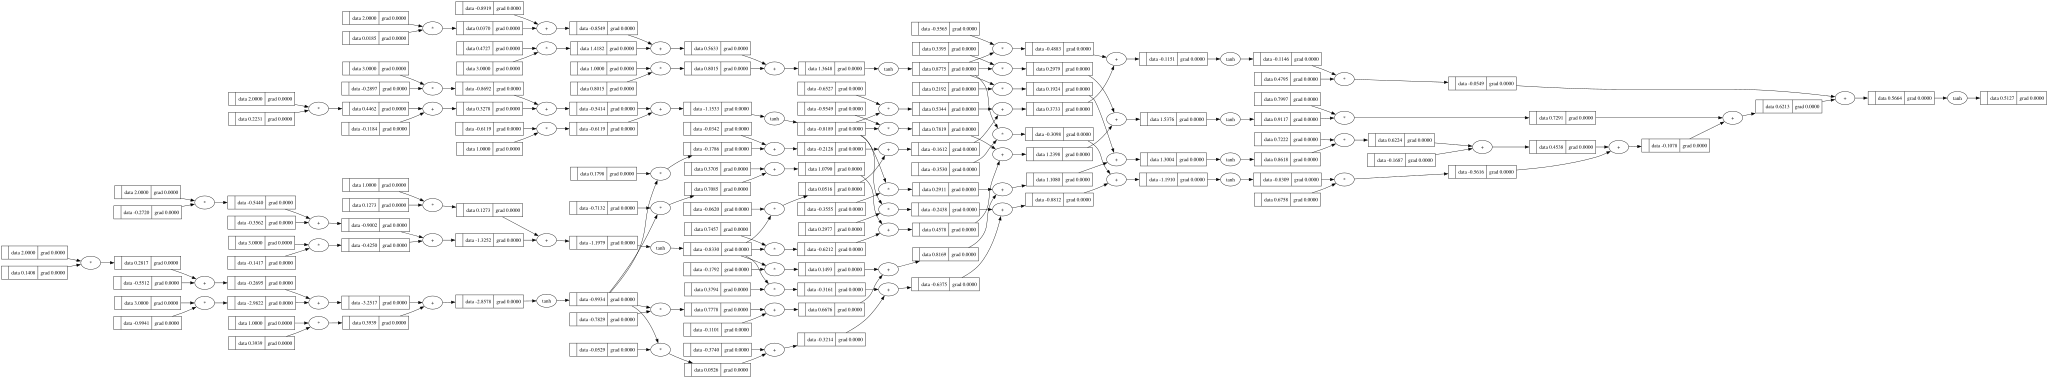

In [193]:
import random


class Neuron:

    def __init__(self,nin):
      self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
      self.b = Value(random.uniform(-1,1))            

    def __call__(self,x):
        act = sum((xi*wi for xi,wi in zip(x,self.w)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs if len(outs) > 1 else outs[0]

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

draw_dot(n(x))




    

In [267]:
x = [2.0,3.0,1.0]
n = MLP(3,[4,4,1])

In [248]:
xs = [
    [2,3,-4],
    [1,2,3],
    [3,4,5],
    [5,6,7]
]
ys = [1,-1,1,1]
    

In [272]:
for k in range(30):
    # forward
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))
    
    # zero gradients BEFORE backward ← you removed this
    for p in n.parameters():
        p.grad = 0.0
    
    # backward
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.01 * p.grad
    
    print(k, loss.data)

0 0.3520601697206955
1 0.3189096040513286
2 0.2965464621006263
3 0.27930241384290105
4 0.26506538184266837
5 0.2528441497773599
6 0.24209613226233345
7 0.23248903107212476
8 0.22380141125580133
9 0.21587598687265983
10 0.20859551031415247
11 0.20186932102754043
12 0.19562532778280328
13 0.18980495019821206
14 0.18435976773518636
15 0.17924920544761874
16 0.17443887838148942
17 0.16989937152142554
18 0.16560531808954246
19 0.16153468861222742
20 0.15766823291650478
21 0.15398903568020217
22 0.15048215798955084
23 0.14713434516171722
24 0.1439337863771535
25 0.14086991533705404
26 0.1379332437656438
27 0.13511522146197896
28 0.1324081179945317
29 0.12980492217109213


In [273]:
ypred

[Value(data=0.9837302136206818),
 Value(data=-0.7544596094923094),
 Value(data=0.7974761329882427),
 Value(data=0.8319695975658026)]